In [1]:
import pandas as pd
import numpy as np

import pickle
import tenseal as ts

import random

import matplotlib.pyplot as plt

In [2]:
with open(
    "../Outputs/Notebook_06/context.pkl",
    "rb"
) as f:

    context_bytes = pickle.load(f)

context = ts.context_from(
    context_bytes
)

print(
    "CKKS Context Loaded"
)

CKKS Context Loaded


In [3]:
with open(
    "../Outputs/Notebook_06/encrypted_embeddings.pkl",
    "rb"
) as f:

    encrypted_embeddings = pickle.load(f)

print(
    len(encrypted_embeddings)
)

14446


In [4]:
compressed_df = pd.read_csv(
    "../Outputs/Notebook_05/compressed_embeddings_with_image.csv"
)

print(
    compressed_df.shape
)

compressed_df.head()

(14446, 129)


,Image,0,1,2,3,4,5,6,7,8,...,118,119,120,121,122,123,124,125,126,127
0,S5000L01.jpg,3.737296,0.673450,0.056452,0.184134,-0.053056,-0.677000,0.585495,-0.260572,-1.047801,...,0.077131,-0.020940,0.142039,-0.762602,-0.168722,0.041406,-0.398751,-0.083328,0.244013,0.100842
1,S5000L02.jpg,-1.532914,0.756785,0.850309,0.411241,1.219522,-0.597589,0.299023,0.266456,-0.990097,...,-0.232056,0.191040,0.007581,-0.229094,-0.210753,0.001012,0.079141,-0.041610,-0.143878,0.187849
2,S5000L04.jpg,-7.827474,-2.796364,0.439108,1.178336,1.665791,-1.602999,-1.164765,1.155259,0.360561,...,0.168901,0.381731,-0.121816,0.024067,-0.045548,-0.153538,-0.177349,-0.297411,-0.029514,0.005127
3,S5000L05.jpg,-0.172677,1.573638,-0.662676,1.244697,1.707050,-0.323209,-0.534795,-1.780205,0.522077,...,0.180868,-0.202145,0.122265,-0.299179,0.391831,0.031457,-0.514450,0.020493,0.346794,0.110880
4,S5000L08.jpg,0.272627,1.821281,0.401272,2.677169,1.050010,-0.718825,-1.095527,-2.068314,1.696303,...,-0.163445,-0.061851,0.021074,-0.272865,-0.002882,0.170077,-0.074081,-0.020336,0.272160,-0.230679


In [5]:
compressed_df["Label"] = compressed_df[
    "Image"
].str.extract(
    r"(S\d+)"
)

print(
    compressed_df["Label"].nunique()
)

compressed_df[
    ["Image","Label"]
].head()

1000


C:\Users\kumar\AppData\Local\Temp\ipykernel_3040\1296452448.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  compressed_df["Label"] = compressed_df[


,Image,Label
0,S5000L01.jpg,S5000
1,S5000L02.jpg,S5000
2,S5000L04.jpg,S5000
3,S5000L05.jpg,S5000
4,S5000L08.jpg,S5000


In [6]:
genuine_pairs = []

persons = compressed_df[
    "Label"
].unique()

for person in persons:

    person_rows = compressed_df[
        compressed_df["Label"] == person
    ].index.tolist()

    if len(person_rows) >= 2:

        genuine_pairs.append(

            (
                person_rows[0],
                person_rows[1]
            )

        )

print(
    len(genuine_pairs)
)

1000


In [7]:
impostor_pairs = []

for _ in range(
    len(genuine_pairs)
):

    p1, p2 = random.sample(
        list(persons),
        2
    )

    idx1 = compressed_df[
        compressed_df["Label"] == p1
    ].index[0]

    idx2 = compressed_df[
        compressed_df["Label"] == p2
    ].index[0]

    impostor_pairs.append(
        (
            idx1,
            idx2
        )
    )

print(
    len(impostor_pairs)
)

1000


In [8]:
print(
    type(
        encrypted_embeddings
    )
)

print(
    len(
        encrypted_embeddings
    )
)

print(
    type(
        encrypted_embeddings[0]
    )
)

<class 'list'>
14446
<class 'bytes'>


In [9]:
encrypted_vectors = []

for enc in encrypted_embeddings:

    encrypted_vectors.append(

        ts.ckks_vector_from(
            context,
            enc
        )

    )

print(
    "Encrypted Vectors Loaded"
)

print(
    len(
        encrypted_vectors
    )
)

Encrypted Vectors Loaded
14446


In [10]:
sample = encrypted_vectors[0]

decrypted = sample.decrypt()

print(
    len(decrypted)
)

print(
    decrypted[:5]
)

128
[0.5268226804455671, 0.09493189906048927, 0.007957642104807244, 0.025956249428304174, -0.007478991648204437]


In [11]:
print(
    "Compressed CSV Shape:"
)

print(
    compressed_df.shape
)

print(
    "Feature Columns:"
)

print(
    len(
        compressed_df.columns[1:]
    )
)

print(
    "Decrypted Length:"
)

print(
    len(
        encrypted_vectors[0].decrypt()
    )
)

Compressed CSV Shape:
(14446, 130)
Feature Columns:
129
Decrypted Length:
128


In [12]:
def encrypted_similarity(enc_vec1, enc_vec2):

    result = enc_vec1.dot(enc_vec2)

    return result.decrypt()[0]

In [13]:
genuine_scores = []

for idx1, idx2 in genuine_pairs:

    score = encrypted_similarity(

        encrypted_vectors[idx1],
        encrypted_vectors[idx2]

    )

    genuine_scores.append(score)

print(
    "Average Genuine Score:",
    np.mean(genuine_scores)
)

Average Genuine Score: 0.3311143858980883


In [14]:
impostor_scores = []

for idx1, idx2 in impostor_pairs:

    score = encrypted_similarity(

        encrypted_vectors[idx1],
        encrypted_vectors[idx2]

    )

    impostor_scores.append(score)

print(
    "Average Impostor Score:",
    np.mean(impostor_scores)
)

Average Impostor Score: 0.013066238090218679


In [15]:
print("Genuine Min :", np.min(genuine_scores))
print("Genuine Max :", np.max(genuine_scores))

print("Impostor Min :", np.min(impostor_scores))
print("Impostor Max :", np.max(impostor_scores))

Genuine Min : -0.5699728080136252
Genuine Max : 0.9999902755135469
Impostor Min : -0.5881651381740708
Impostor Max : 0.7733321292563166


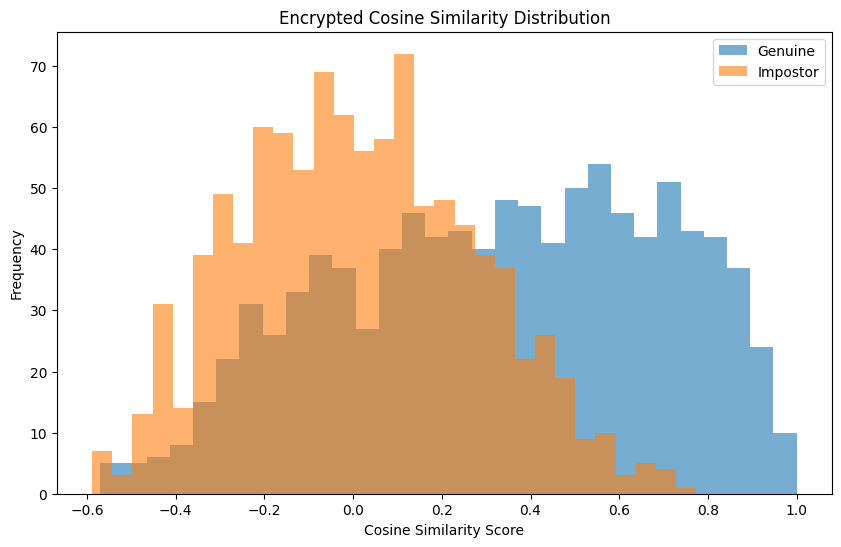

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    genuine_scores,
    bins=30,
    alpha=0.6,
    label="Genuine"
)

plt.hist(
    impostor_scores,
    bins=30,
    alpha=0.6,
    label="Impostor"
)

plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.title("Encrypted Cosine Similarity Distribution")

plt.legend()

plt.savefig(
    "../Outputs/Notebook_07/similarity_distribution.png"
)

plt.show()

In [17]:
threshold = (
    np.mean(genuine_scores)
    +
    np.mean(impostor_scores)
) / 2

print(
    "Threshold:",
    threshold
)

Threshold: 0.17209031199415348


In [18]:
genuine_correct = sum(

    score > threshold

    for score in genuine_scores

)

impostor_correct = sum(

    score < threshold

    for score in impostor_scores

)

total = len(genuine_scores) + len(impostor_scores)

accuracy = (

    genuine_correct
    +
    impostor_correct

) / total * 100

print(
    "Genuine Correct:",
    genuine_correct
)

print(
    "Impostor Correct:",
    impostor_correct
)

print(
    "Authentication Accuracy:",
    accuracy
)

Genuine Correct: 652
Impostor Correct: 723
Authentication Accuracy: 68.75


In [19]:
results_df = pd.DataFrame({

    "Metric": [

        "Average Genuine Score",
        "Average Impostor Score",
        "Threshold",
        "Authentication Accuracy"

    ],

    "Value": [

        np.mean(genuine_scores),
        np.mean(impostor_scores),
        threshold,
        accuracy

    ]

})

results_df.to_csv(

    "../Outputs/Notebook_07/authentication_results.csv",

    index=False

)

print(
    "Results Saved Successfully"
)

Results Saved Successfully
